**Name:  Anjali Arvind Shirke**    
**Roll No : 07**    
**Assignment 11**   

### Aim
For an image classification challenge, create and train a ConvNet in Python using TensorFlow. Also, try to improve the performance of the model by applying various hyperparameter tuning to reduce the overfitting or underfitting problems that might occur. Maintain graphs of comparisons.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')
print(f'Number of classes: {len(set(y_train.flatten()))}')

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 863s 5us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Number of classes: 10


In [4]:
def build_model(dropout_rate=0.25, dense_units=128, learning_rate=0.001, l2_reg=0.0):
    """
    Build a CNN model for CIFAR-10 classification.
    Args:
        dropout_rate: Fraction of neurons to drop (regularization)
        dense_units: Number of neurons in the dense layer
        learning_rate: Learning rate for the Adam optimizer
        l2_reg: L2 regularization factor
    """
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), kernel_regularizer=regularizers.l2(l2_reg)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print('Model builder defined.')

Model builder defined.


In [6]:
print('=== Baseline Model ===')
print('Hyperparameters: dropout_rate=0.0, dense_units=512, learning_rate=0.005, l2_reg=0.0')

model_base = build_model(dropout_rate=0.0, dense_units=512, learning_rate=0.005, l2_reg=0.0)

history_base = model_base.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

=== Baseline Model ===
Hyperparameters: dropout_rate=0.0, dense_units=512, learning_rate=0.005, l2_reg=0.0
Epoch 1/10
625/625 - 23s - 36ms/step - accuracy: 0.3618 - loss: 1.7377 - val_accuracy: 0.4533 - val_loss: 1.4904
Epoch 2/10
625/625 - 20s - 32ms/step - accuracy: 0.4767 - loss: 1.4470 - val_accuracy: 0.5060 - val_loss: 1.3799
Epoch 3/10
625/625 - 20s - 33ms/step - accuracy: 0.5199 - loss: 1.3415 - val_accuracy: 0.5258 - val_loss: 1.3125
Epoch 4/10
625/625 - 20s - 31ms/step - accuracy: 0.5573 - loss: 1.2478 - val_accuracy: 0.5339 - val_loss: 1.3133
Epoch 5/10
625/625 - 21s - 33ms/step - accuracy: 0.5722 - loss: 1.2024 - val_accuracy: 0.5438 - val_loss: 1.3024
Epoch 6/10
625/625 - 21s - 34ms/step - accuracy: 0.5913 - loss: 1.1498 - val_accuracy: 0.5634 - val_loss: 1.2615
Epoch 7/10
625/625 - 39s - 63ms/step - accuracy: 0.6068 - loss: 1.1124 - val_accuracy: 0.5461 - val_loss: 1.3181
Epoch 8/10
625/625 - 20s - 32ms/step - accuracy: 0.6192 - loss: 1.0739 - val_accuracy: 0.5506 - val_lo

In [7]:
print('=== Tuned Model ===')
print('Hyperparameters: dropout_rate=0.4, dense_units=256, learning_rate=0.001, l2_reg=0.0001')

model_tuned = build_model(dropout_rate=0.4, dense_units=256, learning_rate=0.001, l2_reg=0.0001)

history_tuned = model_tuned.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

=== Tuned Model ===
Hyperparameters: dropout_rate=0.4, dense_units=256, learning_rate=0.001, l2_reg=0.0001
Epoch 1/10
625/625 - 19s - 31ms/step - accuracy: 0.4003 - loss: 1.6607 - val_accuracy: 0.5067 - val_loss: 1.4238
Epoch 2/10
625/625 - 21s - 33ms/step - accuracy: 0.5481 - loss: 1.3086 - val_accuracy: 0.5821 - val_loss: 1.2119
Epoch 3/10
625/625 - 21s - 33ms/step - accuracy: 0.6115 - loss: 1.1561 - val_accuracy: 0.6254 - val_loss: 1.1288
Epoch 4/10
625/625 - 20s - 32ms/step - accuracy: 0.6565 - loss: 1.0481 - val_accuracy: 0.6678 - val_loss: 1.0190
Epoch 5/10
625/625 - 17s - 27ms/step - accuracy: 0.6877 - loss: 0.9745 - val_accuracy: 0.6679 - val_loss: 1.0184
Epoch 6/10
625/625 - 23s - 36ms/step - accuracy: 0.7088 - loss: 0.9198 - val_accuracy: 0.6951 - val_loss: 0.9500
Epoch 7/10
625/625 - 18s - 30ms/step - accuracy: 0.7286 - loss: 0.8717 - val_accuracy: 0.7129 - val_loss: 0.9190
Epoch 8/10
625/625 - 18s - 29ms/step - accuracy: 0.7480 - loss: 0.8200 - val_accuracy: 0.7148 - val_lo

In [8]:
test_loss_base, test_acc_base = model_base.evaluate(x_test, y_test, verbose=0)
test_loss_tuned, test_acc_tuned = model_tuned.evaluate(x_test, y_test, verbose=0)

print(f'Baseline Model - Test Accuracy: {test_acc_base:.4f}, Test Loss: {test_loss_base:.4f}')
print(f'Tuned Model    - Test Accuracy: {test_acc_tuned:.4f}, Test Loss: {test_loss_tuned:.4f}')

Baseline Model - Test Accuracy: 0.5389, Test Loss: 1.4121
Tuned Model    - Test Accuracy: 0.7246, Test Loss: 0.9410


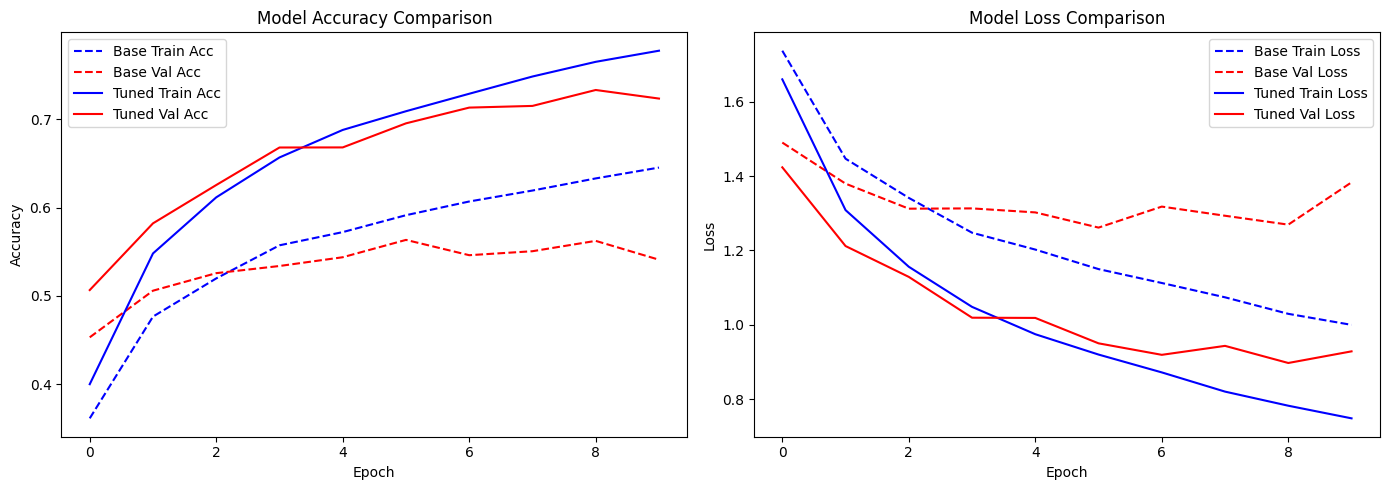

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history_base.history['accuracy'], 'b--', label='Base Train Acc')
ax1.plot(history_base.history['val_accuracy'], 'r--', label='Base Val Acc')
ax1.plot(history_tuned.history['accuracy'], 'b-', label='Tuned Train Acc')
ax1.plot(history_tuned.history['val_accuracy'], 'r-', label='Tuned Val Acc')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history_base.history['loss'], 'b--', label='Base Train Loss')
ax2.plot(history_base.history['val_loss'], 'r--', label='Base Val Loss')
ax2.plot(history_tuned.history['loss'], 'b-', label='Tuned Train Loss')
ax2.plot(history_tuned.history['val_loss'], 'r-', label='Tuned Val Loss')
ax2.set_title('Model Loss Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

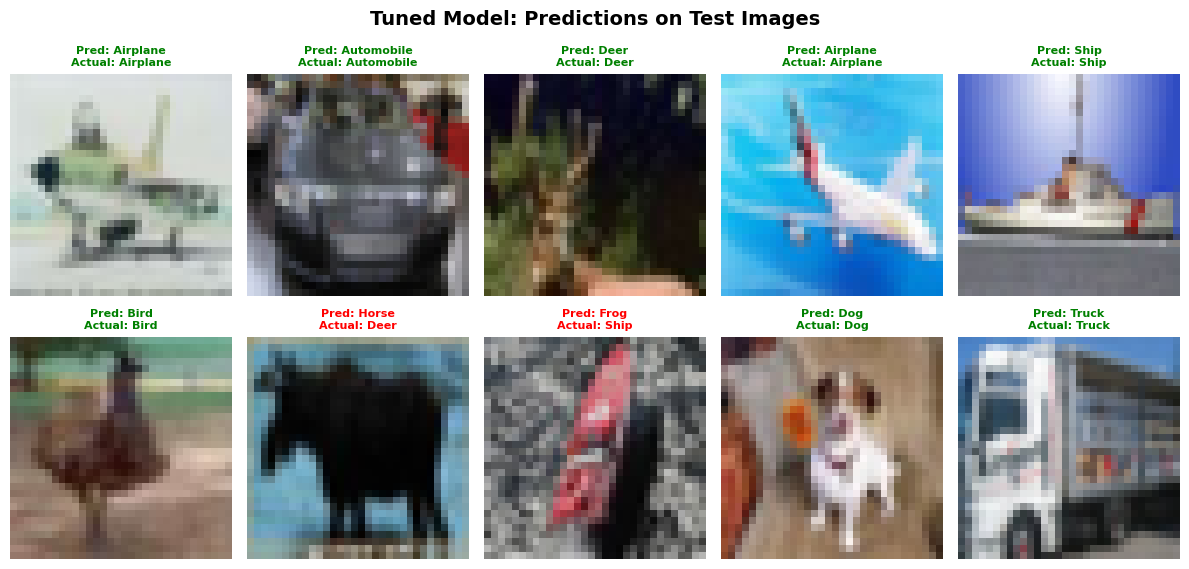

In [10]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

y_pred_tuned = np.argmax(model_tuned.predict(x_test, verbose=0), axis=1)
y_true = y_test.flatten()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    idx = np.random.randint(0, len(x_test))
    ax = axes[i//5, i%5]
    ax.imshow(x_test[idx])
    predicted_class = class_names[y_pred_tuned[idx]]
    actual_class = class_names[y_true[idx]]
    color = 'green' if y_pred_tuned[idx] == y_true[idx] else 'red'
    ax.set_title(f'Pred: {predicted_class}\nActual: {actual_class}', color=color, fontweight='bold', fontsize=8)
    ax.axis('off')
plt.suptitle('Tuned Model: Predictions on Test Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()